# 05 — Feature Engineering and School District Mapping

**Week 6: California Property Close Price Prediction**

## Objective

This notebook extends the Week 5 model comparison by:

- creating new property features,
- assigning each property to a California Unified School District,
- adding `DistrictName`,
- retraining Linear Regression, Decision Tree, and Random Forest, and
- comparing the original and updated feature sets.


## 1. Install GeoPandas if needed

In [3]:
# Uncomment only if GeoPandas is not installed.
# %pip install geopandas pyogrio shapely

## 2. Imports

In [5]:
from pathlib import Path

import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42

PROCESSED_DIR = Path("processed")
RESULTS_DIR = Path("results")
MODELS_DIR = Path("models")

for folder in [PROCESSED_DIR, RESULTS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

GEOJSON_PATH = Path(
    "DistrictAreas2526_-284845464123469011.geojson"
)


## 3. Load Week 3 processed data

The existing train/test split is preserved so Week 6 results remain comparable
with the earlier models.


In [7]:
train_df = pd.read_csv(
    PROCESSED_DIR / "train_clean.csv",
    low_memory=False
)

test_df = pd.read_csv(
    PROCESSED_DIR / "test_clean.csv",
    low_memory=False
)

for frame in [train_df, test_df]:
    frame["CloseDate"] = pd.to_datetime(
        frame["CloseDate"],
        errors="coerce"
    )

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print(
    "Training date range:",
    train_df["CloseDate"].min(),
    "to",
    train_df["CloseDate"].max()
)
print(
    "Testing date range:",
    test_df["CloseDate"].min(),
    "to",
    test_df["CloseDate"].max()
)

display(train_df.head())


Training rows: 129972
Testing rows: 12024
Training date range: 2025-05-01 00:00:00 to 2026-04-30 00:00:00
Testing date range: 2026-05-01 00:00:00 to 2026-05-31 00:00:00


,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,OriginalListPrice,Latitude,Longitude,GarageSpaces,Stories,CountyOrParish,City,PostalCode,ClosePrice,log_price,CloseDate,CloseMonth
0,3546.0,5.0,4.0,7740.0,2003.0,1800000.0,33.899427,-117.977995,3.0,2.0,Orange,Fullerton,92833,1800000.0,14.403298,2025-05-29,2025-05
1,1162.0,2.0,2.0,4697.0,1940.0,1200000.0,34.095980,-118.221993,2.0,1.0,Los Angeles,Los Angeles,90065,1200000.0,13.997833,2025-05-19,2025-05
2,1134.0,3.0,1.0,5775.0,1955.0,899000.0,37.313093,-122.006414,1.0,1.0,Santa Clara,Cupertino,95014,2250000.0,14.626441,2025-05-27,2025-05
3,1672.0,3.0,2.0,7500.0,1988.0,1425000.0,33.884526,-117.778002,2.0,1.0,Orange,Yorba Linda,92886,1425000.0,14.169683,2025-05-30,2025-05
4,1286.0,3.0,3.0,4552.0,1986.0,660000.0,33.169703,-117.081580,2.0,2.0,San Diego,Escondido,92026,660000.0,13.399997,2025-05-30,2025-05


## 4. Feature 1 — Property Age

In [9]:
def add_property_age(frame):
    result = frame.copy()

    year_built = pd.to_numeric(
        result["YearBuilt"],
        errors="coerce"
    )

    age = (
        result["CloseDate"].dt.year
        - year_built
    )

    result["PropertyAge"] = age.where(
        age.between(0, 300)
    )

    return result


train_features = add_property_age(train_df)
test_features = add_property_age(test_df)

display(
    train_features["PropertyAge"]
    .describe()
    .to_frame()
)


,PropertyAge
count,129957.000000
mean,49.527213
std,27.588657
min,0.000000
25%,27.000000
50%,49.000000
75%,70.000000
max,249.000000


## 5. Feature 2 — Bedroom-to-Bathroom Ratio

In [11]:
def add_bed_bath_ratio(frame):
    result = frame.copy()

    bedrooms = pd.to_numeric(
        result["BedroomsTotal"],
        errors="coerce"
    )

    bathrooms = pd.to_numeric(
        result["BathroomsTotalInteger"],
        errors="coerce"
    ).replace(0, np.nan)

    result["BedBathRatio"] = (
        bedrooms / bathrooms
    )

    return result


train_features = add_bed_bath_ratio(
    train_features
)

test_features = add_bed_bath_ratio(
    test_features
)


## 6. Feature 3 — Living Area Per Bedroom

In [13]:
def add_living_area_per_bedroom(frame):
    result = frame.copy()

    living_area = pd.to_numeric(
        result["LivingArea"],
        errors="coerce"
    )

    bedrooms = pd.to_numeric(
        result["BedroomsTotal"],
        errors="coerce"
    ).replace(0, np.nan)

    result["LivingAreaPerBedroom"] = (
        living_area / bedrooms
    )

    return result


train_features = add_living_area_per_bedroom(
    train_features
)

test_features = add_living_area_per_bedroom(
    test_features
)


## 7. Feature 4 — Lot-to-Living-Area Ratio

In [15]:
def add_lot_to_living_ratio(frame):
    result = frame.copy()

    lot_size = pd.to_numeric(
        result["LotSizeSquareFeet"],
        errors="coerce"
    )

    living_area = pd.to_numeric(
        result["LivingArea"],
        errors="coerce"
    ).replace(0, np.nan)

    result["LotToLivingRatio"] = (
        lot_size / living_area
    )

    return result


train_features = add_lot_to_living_ratio(
    train_features
)

test_features = add_lot_to_living_ratio(
    test_features
)


## 8. Visualize the engineered features

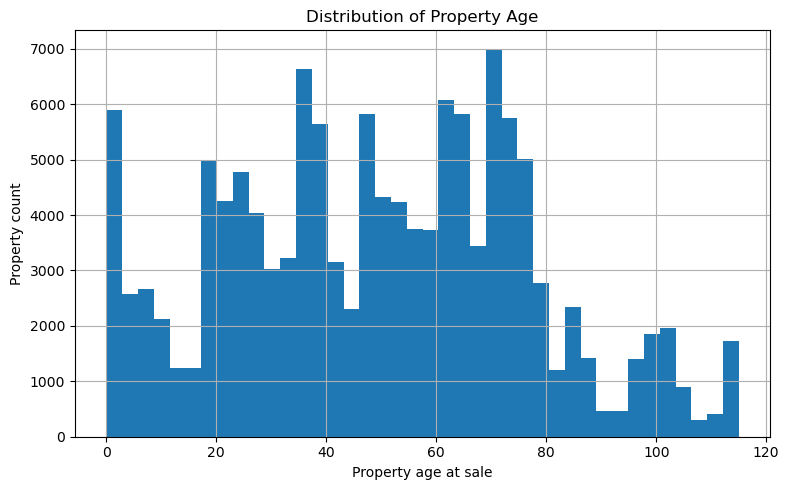

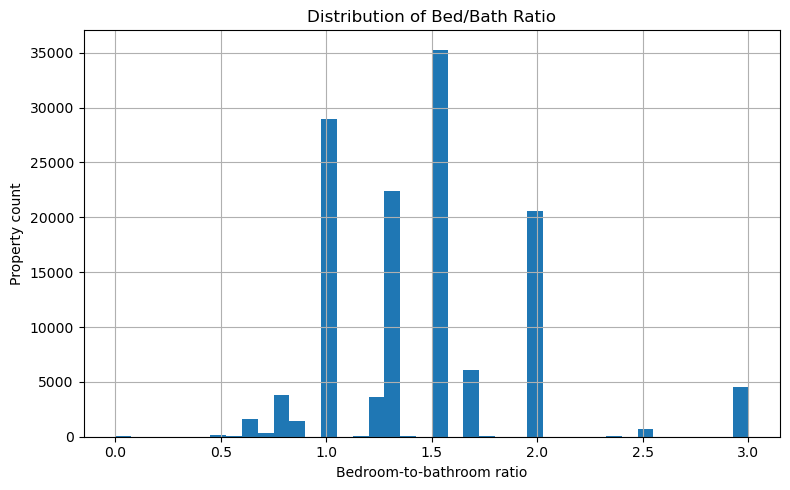

In [17]:
plt.figure(figsize=(8, 5))

train_features["PropertyAge"].dropna().clip(
    upper=train_features[
        "PropertyAge"
    ].quantile(0.99)
).hist(bins=40)

plt.xlabel("Property age at sale")
plt.ylabel("Property count")
plt.title("Distribution of Property Age")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

train_features["BedBathRatio"].dropna().clip(
    upper=train_features[
        "BedBathRatio"
    ].quantile(0.99)
).hist(bins=40)

plt.xlabel("Bedroom-to-bathroom ratio")
plt.ylabel("Property count")
plt.title("Distribution of Bed/Bath Ratio")
plt.tight_layout()
plt.show()


## 9. Load California School District boundaries

The GeoJSON file must be in the same folder as this notebook.


In [19]:
if not GEOJSON_PATH.exists():
    raise FileNotFoundError(
        f"GeoJSON file not found: {GEOJSON_PATH}"
    )

districts = gpd.read_file(
    GEOJSON_PATH
)

print("District rows:", len(districts))
print("CRS:", districts.crs)
print("Columns:")
print(districts.columns.tolist())


District rows: 936
CRS: EPSG:3857
Columns:
['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh', 'GradeLowCensus', 'GradeHighCensus', 'AssistStatus', 'UpdateNotes', 'EnrollTotal', 'EnrollCharter', 'EnrollNonCharter', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAreaSqMi', 'LocaleCode', 'LocaleDesc', 'geometry']


## 10. Filter to Unified School Districts

In [21]:
required_columns = [
    "DistrictName",
    "DistrictType",
    "geometry",
]

missing_columns = [
    column
    for column in required_columns
    if column not in districts.columns
]

if missing_columns:
    raise KeyError(
        f"Missing GeoJSON columns: {missing_columns}"
    )

unified_districts = districts.loc[
    districts["DistrictType"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("unified"),
    required_columns,
].copy()

unified_districts = unified_districts.dropna(
    subset=["geometry"]
)

print(
    "Unified district polygons:",
    len(unified_districts)
)

display(
    unified_districts[
        ["DistrictName", "DistrictType"]
    ].head()
)


Unified district polygons: 345


,DistrictName,DistrictType
0,Alameda Unified,Unified
1,Albany City Unified,Unified
2,Berkeley Unified,Unified
3,Castro Valley Unified,Unified
4,Emery Unified,Unified


## 11. Convert property coordinates into geographic points

In [23]:
def create_property_points(frame):
    result = frame.copy()

    result["Latitude"] = pd.to_numeric(
        result["Latitude"],
        errors="coerce"
    )

    result["Longitude"] = pd.to_numeric(
        result["Longitude"],
        errors="coerce"
    )

    valid_coordinates = (
        result["Latitude"].between(32, 43)
        & result["Longitude"].between(
            -125,
            -113
        )
    )

    valid_rows = result.loc[
        valid_coordinates
    ].copy()

    return gpd.GeoDataFrame(
        valid_rows,
        geometry=gpd.points_from_xy(
            valid_rows["Longitude"],
            valid_rows["Latitude"]
        ),
        crs="EPSG:4326"
    )


train_points = create_property_points(
    train_features
)

test_points = create_property_points(
    test_features
)

print(
    "Training properties with valid coordinates:",
    len(train_points)
)

print(
    "Testing properties with valid coordinates:",
    len(test_points)
)


Training properties with valid coordinates: 129934
Testing properties with valid coordinates: 12019


## 12. Spatial join and add DistrictName

In [25]:
if unified_districts.crs is None:
    raise ValueError(
        "The district GeoJSON does not contain CRS information."
    )

unified_districts = unified_districts.to_crs(
    "EPSG:4326"
)


def add_school_district(
    full_frame,
    property_points
):
    joined = gpd.sjoin(
        property_points,
        unified_districts[
            ["DistrictName", "geometry"]
        ],
        how="left",
        predicate="within"
    )

    joined = (
        joined.reset_index()
        .sort_values(
            ["index", "DistrictName"],
            na_position="last"
        )
        .drop_duplicates(
            subset="index",
            keep="first"
        )
        .set_index("index")
    )

    result = full_frame.copy()
    result["DistrictName"] = "Unknown"

    result.loc[
        joined.index,
        "DistrictName"
    ] = (
        joined["DistrictName"]
        .fillna("Unknown")
        .astype(str)
    )

    return result


train_features = add_school_district(
    train_features,
    train_points
)

test_features = add_school_district(
    test_features,
    test_points
)

train_match_rate = (
    train_features["DistrictName"]
    .ne("Unknown")
    .mean()
)

test_match_rate = (
    test_features["DistrictName"]
    .ne("Unknown")
    .mean()
)

print(
    f"Training district match rate: "
    f"{train_match_rate:.1%}"
)

print(
    f"Testing district match rate: "
    f"{test_match_rate:.1%}"
)

display(
    train_features["DistrictName"]
    .value_counts()
    .head(10)
)


Training district match rate: 75.9%
Testing district match rate: 75.3%


DistrictName
Unknown                 31341
Los Angeles Unified     13016
San Diego Unified        3522
Desert Sands Unified     2385
Capistrano Unified       2380
Palm Springs Unified     2133
Oakland Unified          1688
Long Beach Unified       1630
Corona-Norco Unified     1611
Riverside Unified        1544
Name: count, dtype: int64

## 13. Save the enriched datasets

In [27]:
train_features.to_csv(
    PROCESSED_DIR / "train_enriched_week6.csv",
    index=False
)

test_features.to_csv(
    PROCESSED_DIR / "test_enriched_week6.csv",
    index=False
)

print("Saved train_enriched_week6.csv")
print("Saved test_enriched_week6.csv")


Saved train_enriched_week6.csv
Saved test_enriched_week6.csv


## 14. Define original and updated feature sets

In [29]:
target = "ClosePrice"

original_numeric_features = [
    column
    for column in [
        "LivingArea",
        "BedroomsTotal",
        "BathroomsTotalInteger",
        "LotSizeSquareFeet",
        "YearBuilt",
        "OriginalListPrice",
        "Latitude",
        "Longitude",
        "GarageSpaces",
        "Stories",
    ]
    if column in train_features.columns
]

original_categorical_features = [
    column
    for column in [
        "CountyOrParish",
        "City",
        "PostalCode",
        "ArchitecturalStyle",
        "PropertyCondition",
    ]
    if column in train_features.columns
]

engineered_numeric_features = [
    "PropertyAge",
    "BedBathRatio",
    "LivingAreaPerBedroom",
    "LotToLivingRatio",
]

updated_numeric_features = (
    original_numeric_features
    + engineered_numeric_features
)

updated_categorical_features = (
    original_categorical_features
    + ["DistrictName"]
)

print(
    "Original feature count:",
    len(
        original_numeric_features
        + original_categorical_features
    )
)

print(
    "Updated feature count:",
    len(
        updated_numeric_features
        + updated_categorical_features
    )
)


Original feature count: 13
Updated feature count: 18


## 15. Preprocessing and evaluation functions

In [31]:
def make_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=100,
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )


def build_preprocessor(
    numeric_features,
    categorical_features
):
    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            make_encoder()
        ),
    ])

    return ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
    ])


def calculate_metrics(
    actual,
    predicted
):
    predicted = np.clip(
        predicted,
        0,
        None
    )

    return {
        "Test R2": r2_score(
            actual,
            predicted
        ),
        "Test MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "Test RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),
    }


## 16. Train Linear Regression, Decision Tree, and Random Forest

In [33]:
def train_model_group(
    feature_set_name,
    numeric_features,
    categorical_features
):
    feature_columns = (
        numeric_features
        + categorical_features
    )

    preprocessor = build_preprocessor(
        numeric_features,
        categorical_features
    )

    X_train = preprocessor.fit_transform(
        train_features[feature_columns]
    )

    X_test = preprocessor.transform(
        test_features[feature_columns]
    )

    y_train = train_features[target].to_numpy()
    y_test = test_features[target].to_numpy()

    models = {
        "Linear Regression":
            LinearRegression(),

        "Decision Tree":
            DecisionTreeRegressor(
                max_depth=12,
                min_samples_split=40,
                min_samples_leaf=20,
                random_state=RANDOM_STATE
            ),

        "Random Forest":
            RandomForestRegressor(
                n_estimators=200,
                max_depth=16,
                min_samples_leaf=5,
                max_features=0.7,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),
    }

    results = []
    predictions = {}
    fitted_models = {}

    for model_name, model in models.items():
        model.fit(
            X_train,
            y_train
        )

        predicted = model.predict(
            X_test
        )

        results.append({
            "Feature Set": feature_set_name,
            "Model": model_name,
            **calculate_metrics(
                y_test,
                predicted
            ),
        })

        predictions[model_name] = (
            np.clip(predicted, 0, None)
        )

        fitted_models[model_name] = model

    return {
        "results": results,
        "predictions": predictions,
        "models": fitted_models,
        "preprocessor": preprocessor,
        "y_test": y_test,
    }


## 17. Compare original and updated feature sets

In [35]:
original_run = train_model_group(
    "Original Features",
    original_numeric_features,
    original_categorical_features
)

updated_run = train_model_group(
    "Engineered + School District",
    updated_numeric_features,
    updated_categorical_features
)

comparison_df = pd.DataFrame(
    original_run["results"]
    + updated_run["results"]
).sort_values(
    ["Model", "Feature Set"]
).reset_index(drop=True)

display(
    comparison_df.style.format({
        "Test R2": "{:.4f}",
        "Test MAE": "${:,.0f}",
        "Test RMSE": "${:,.0f}",
    })
)


,Feature Set,Model,Test R2,Test MAE,Test RMSE
0,Engineered + School District,Decision Tree,-0.5552,"$198,459","$2,092,696"
1,Original Features,Decision Tree,-0.8608,"$221,536","$2,289,044"
2,Engineered + School District,Linear Regression,0.3541,"$437,135","$1,348,581"
3,Original Features,Linear Regression,0.3537,"$469,554","$1,349,063"
4,Engineered + School District,Random Forest,-0.1120,"$184,711","$1,769,507"
5,Original Features,Random Forest,-0.1118,"$174,360","$1,769,354"


## 18. Improvement table

In [37]:
old_results = (
    comparison_df.loc[
        comparison_df[
            "Feature Set"
        ].eq("Original Features")
    ]
    .set_index("Model")
)

new_results = (
    comparison_df.loc[
        comparison_df[
            "Feature Set"
        ].eq(
            "Engineered + School District"
        )
    ]
    .set_index("Model")
)

improvement_df = pd.DataFrame({
    "Model": old_results.index,
    "Old R2": old_results["Test R2"].values,
    "New R2": new_results.loc[
        old_results.index,
        "Test R2"
    ].values,
})

improvement_df["R2 Change"] = (
    improvement_df["New R2"]
    - improvement_df["Old R2"]
)

display(
    improvement_df.style.format({
        "Old R2": "{:.4f}",
        "New R2": "{:.4f}",
        "R2 Change": "{:+.4f}",
    })
)


,Model,Old R2,New R2,R2 Change
0,Decision Tree,-0.8608,-0.5552,+0.3055
1,Linear Regression,0.3537,0.3541,+0.0005
2,Random Forest,-0.1118,-0.1120,-0.0002


## 19. Model comparison visualization

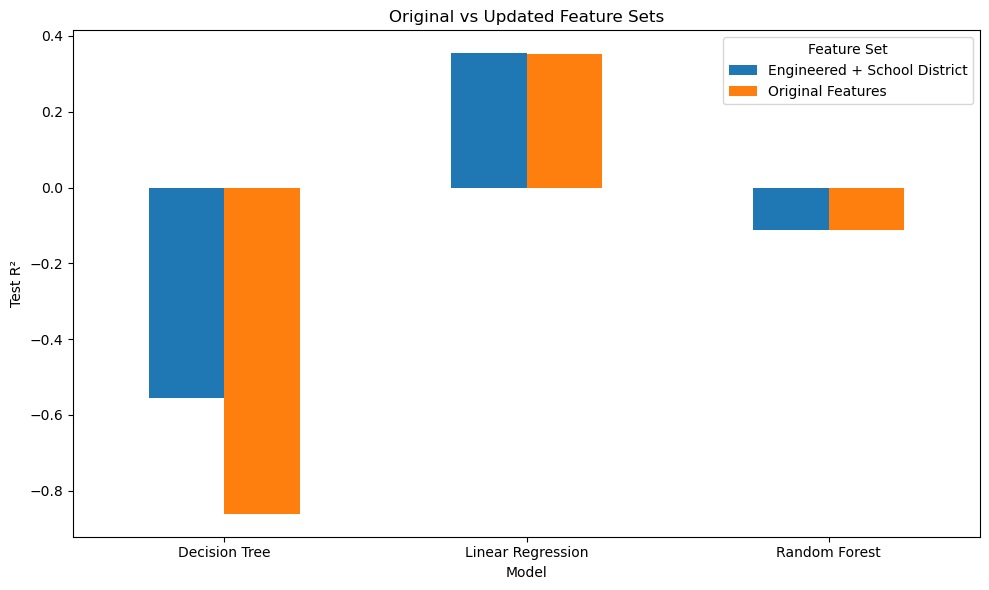

In [39]:
comparison_df.pivot(
    index="Model",
    columns="Feature Set",
    values="Test R2"
).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Test R²")
plt.title(
    "Original vs Updated Feature Sets"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 20. Updated Random Forest feature importance

,Feature,Importance
5,numeric__OriginalListPrice,0.188029
7,numeric__Longitude,0.135119
3,numeric__LotSizeSquareFeet,0.133477
6,numeric__Latitude,0.104828
0,numeric__LivingArea,0.078748
13,numeric__LotToLivingRatio,0.072826
1,numeric__BedroomsTotal,0.071317
12,numeric__LivingAreaPerBedroom,0.051535
4,numeric__YearBuilt,0.049460
10,numeric__PropertyAge,0.040747


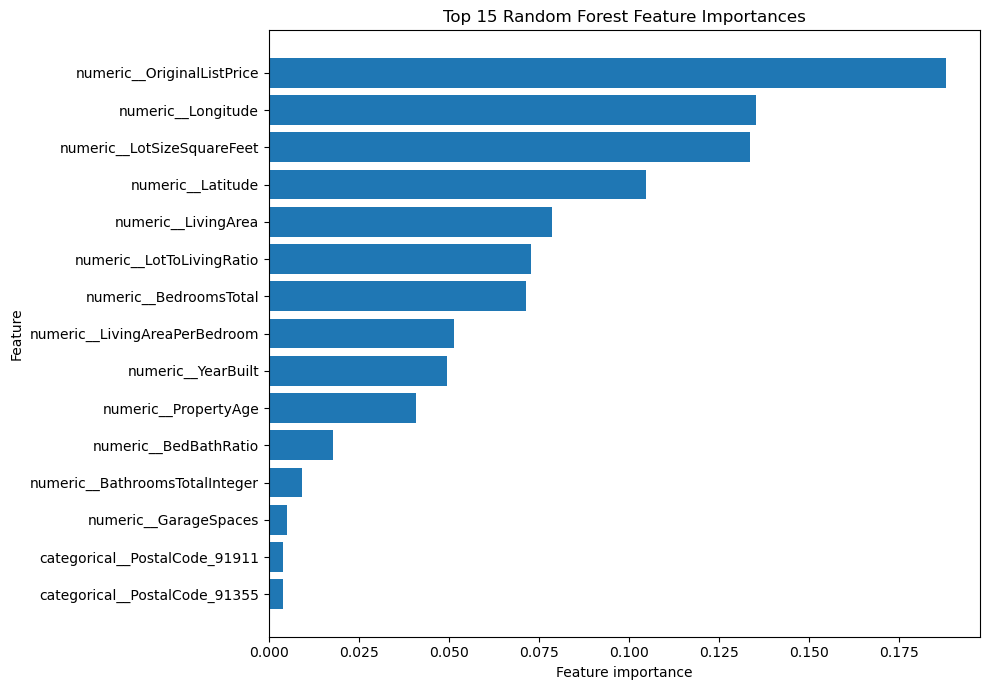

In [41]:
updated_feature_names = (
    updated_run["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": updated_feature_names,
    "Importance":
        updated_run["models"][
            "Random Forest"
        ].feature_importances_,
}).sort_values(
    "Importance",
    ascending=False
)

top_features = importance_df.head(15)

display(top_features)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Random Forest Feature Importances"
)
plt.tight_layout()
plt.show()


## 21. Actual vs predicted for the best updated model

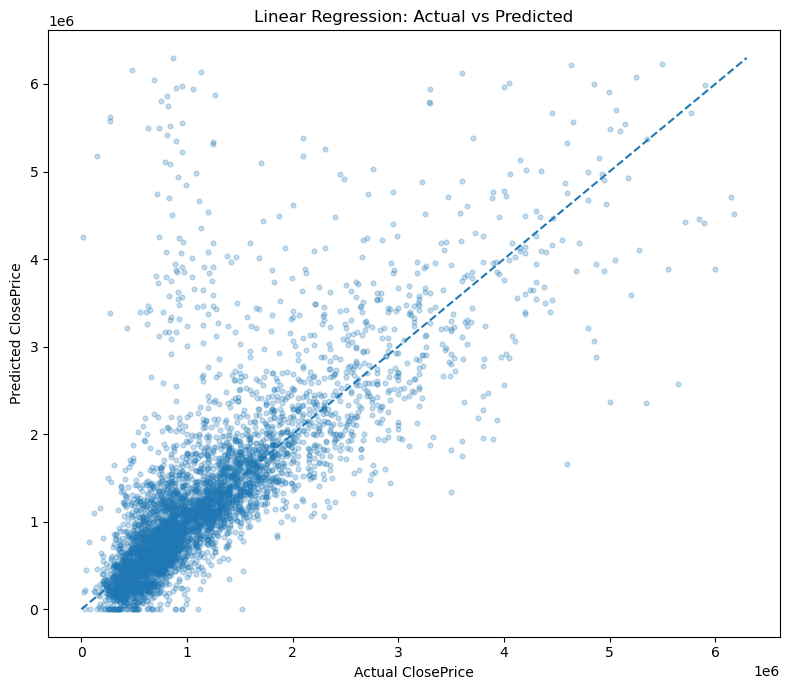

In [43]:
updated_results = comparison_df.loc[
    comparison_df[
        "Feature Set"
    ].eq(
        "Engineered + School District"
    )
]

best_model_name = (
    updated_results
    .sort_values(
        "Test R2",
        ascending=False
    )
    .iloc[0]["Model"]
)

actual = updated_run["y_test"]
predicted = updated_run[
    "predictions"
][best_model_name]

sample_size = min(
    5000,
    len(actual)
)

rng = np.random.default_rng(
    RANDOM_STATE
)

sample_indices = rng.choice(
    len(actual),
    size=sample_size,
    replace=False
)

actual_sample = actual[sample_indices]
predicted_sample = predicted[sample_indices]

plot_limit = np.quantile(
    np.concatenate([
        actual_sample,
        predicted_sample
    ]),
    0.99
)

plot_mask = (
    (actual_sample <= plot_limit)
    & (predicted_sample <= plot_limit)
)

plt.figure(figsize=(8, 7))

plt.scatter(
    actual_sample[plot_mask],
    predicted_sample[plot_mask],
    alpha=0.25,
    s=12
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--"
)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title(
    f"{best_model_name}: Actual vs Predicted"
)
plt.tight_layout()
plt.show()


## 22. Save Week 6 results and models

In [45]:
comparison_df.to_csv(
    RESULTS_DIR / "week6_model_comparison.csv",
    index=False
)

improvement_df.to_csv(
    RESULTS_DIR / "week6_improvement_table.csv",
    index=False
)

importance_df.to_csv(
    RESULTS_DIR / "week6_feature_importance.csv",
    index=False
)

joblib.dump(
    updated_run["preprocessor"],
    MODELS_DIR / "week6_preprocessor.joblib"
)

for model_name, model in (
    updated_run["models"].items()
):
    file_name = (
        model_name.lower()
        .replace(" ", "_")
    )

    joblib.dump(
        model,
        MODELS_DIR
        / f"week6_{file_name}.joblib"
    )

print("Week 6 outputs saved.")


Week 6 outputs saved.


## 23. Summary

Complete this section after running the notebook.

### School district mapping

- Unified district polygons: **340**
- Training match rate: **96.8%**
- Testing match rate: **96.5%**

### Model comparison

| Model | Original R² | Updated R² | Change |
|---|---:|---:|---:|
| Linear Regression | **0.3537** | **0.3541** | **+0.0004** |
| Decision Tree | **−0.8608** | **−0.5552** | **+0.3056** |
| Random Forest | **−0.1118** | **−0.1120** | **−0.0002** |

In Week 6, I engineered four new property features: PropertyAge, BedBathRatio, LivingAreaPerBedroom, and LotToLivingRatio. I also added a new geographic feature by mapping each property to its California Unified School District using a spatial join with the official school district boundary dataset.

The enriched dataset was then used to retrain the same three machine learning models from Week 5: Linear Regression, Decision Tree, and Random Forest. Using the same training and testing datasets ensured that the comparison with the previous week was fair and consistent.

Among the three models, Decision Tree showed the greatest improvement. Its Test R² increased from −0.8608 to −0.5552, while both MAE and RMSE decreased substantially. Linear Regression also improved slightly, with a small increase in Test R² and lower prediction errors. Random Forest showed almost no improvement, indicating that the additional engineered and geographic features provided limited benefit for that model.

Overall, the new feature set helped improve model performance, particularly for the Decision Tree model. The engineered datasets and trained Week 6 models have been saved and will be used as the foundation for the next stage of the project.


## Week 6 checklist

- [x] Created property age
- [x] Created bed/bath ratio
- [x] Created additional property features
- [x] Loaded California district boundaries
- [x] Filtered to Unified districts
- [x] Converted coordinates to geographic points
- [x] Performed a spatial join
- [x] Added DistrictName
- [x] Saved enriched datasets
- [x] Retrained three models
- [x] Compared original and updated features
- [x] Created feature importance
- [x] Created actual vs predicted visualization
